In [20]:
import random
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

DATASET_DIR = Path("dataset/fracture_segmentation")

In [21]:
all_files = sorted((DATASET_DIR / "train").glob("patient_*.npz")) + sorted(
    (DATASET_DIR / "validation").glob("patient_*.npz")
)
assert all_files, f"No .npz files found under {DATASET_DIR}"

npz_path = random.choice(all_files)
print(f"File : {npz_path}")

npz = np.load(npz_path)
image = npz["image"][0]  # (D, H, W)
gt_label = npz["gt_label"][0]  # (D, H, W)
fdm_weights = npz["fdm_weights"][0]  # (D, H, W)

print(f"\nImage      shape={image.shape}  range=[{image.min():.3f}, {image.max():.3f}]")
print(f"GT labels  unique={np.unique(gt_label)}")
print(f"  Background (0): {(gt_label == 0).sum():>10,} voxels")
print(f"  Major      (1): {(gt_label == 1).sum():>10,} voxels")
print(f"  Minor      (2): {(gt_label == 2).sum():>10,} voxels")
print(f"\nFDM weights  range=[{fdm_weights.min():.4f}, {fdm_weights.max():.4f}]")
fg_mask = gt_label > 0
print(
    f"  Foreground mean={fdm_weights[fg_mask].mean():.4f}  "
    f"std={fdm_weights[fg_mask].std():.4f}"
)

File : dataset/fracture_segmentation/train/patient_124_sacrum_patch_00.npz

Image      shape=(96, 96, 96)  range=[0.000, 0.931]
GT labels  unique=[0 1 2]
  Background (0):    809,577 voxels
  Major      (1):     74,173 voxels
  Minor      (2):        986 voxels

FDM weights  range=[0.2000, 1.7090]
  Foreground mean=1.3016  std=0.3236


In [22]:
# Auto-pick the slice with the most minor-fragment voxels; override SLICE to inspect another.
minor_counts = (gt_label == 2).sum(axis=(1, 2))
best_slice = int(np.argmax(minor_counts))
print(f"Best slice (most minor-fragment voxels): {best_slice} / {image.shape[0] - 1}")

SLICE = best_slice  # <-- change me

Best slice (most minor-fragment voxels): 90 / 95


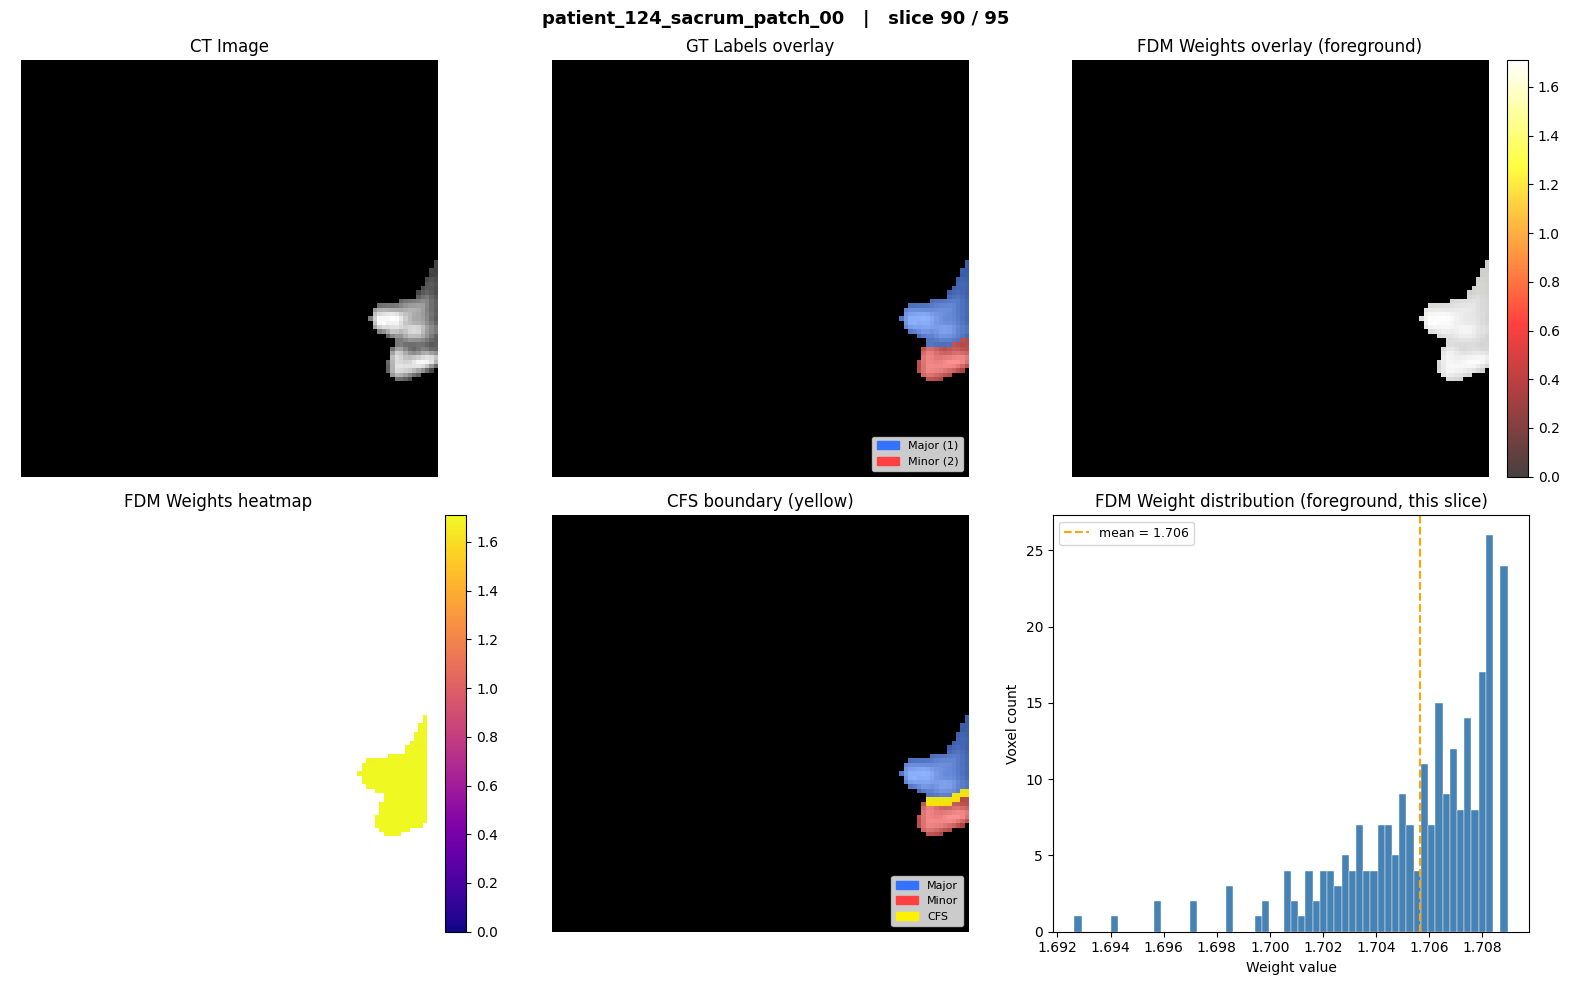

In [23]:
def find_cfs_2d(label_2d: np.ndarray) -> np.ndarray:
    """6-connected CFS detection on a 2-D label slice."""
    cfs = np.zeros_like(label_2d, dtype=bool)
    for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        shifted = np.roll(label_2d, dy, axis=0)
        shifted = np.roll(shifted, dx, axis=1)
        cfs |= (label_2d > 0) & (shifted > 0) & (shifted != label_2d)
    return cfs


sl_img = image[SLICE]
sl_gt = gt_label[SLICE]
sl_wt = fdm_weights[SLICE]
sl_cfs = find_cfs_2d(sl_gt)

# RGBA overlays
label_rgba = np.zeros((*sl_gt.shape, 4))
label_rgba[sl_gt == 1] = [0.2, 0.45, 1.0, 0.55]  # blue  – major
label_rgba[sl_gt == 2] = [1.0, 0.25, 0.25, 0.55]  # red   – minor

cfs_rgba = np.zeros((*sl_cfs.shape, 4))
cfs_rgba[sl_cfs] = [1.0, 0.95, 0.0, 0.9]  # yellow – CFS

wt_fg = np.where(sl_gt > 0, sl_wt, np.nan)  # mask background for heatmap
wt_max = np.nanmax(wt_fg) if not np.all(np.isnan(wt_fg)) else 1.0

# ── 2 × 3 figure ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    f"{npz_path.stem}   |   slice {SLICE} / {image.shape[0] - 1}",
    fontsize=13,
    fontweight="bold",
)

# 1. Raw CT
ax = axes[0, 0]
ax.imshow(sl_img, cmap="gray", interpolation="nearest")
ax.set_title("CT Image")
ax.axis("off")

# 2. GT label overlay
ax = axes[0, 1]
ax.imshow(sl_img, cmap="gray", interpolation="nearest")
ax.imshow(label_rgba, interpolation="nearest")
ax.set_title("GT Labels overlay")
ax.axis("off")
ax.legend(
    handles=[
        mpatches.Patch(color=[0.2, 0.45, 1.0], label="Major (1)"),
        mpatches.Patch(color=[1.0, 0.25, 0.25], label="Minor (2)"),
    ],
    loc="lower right",
    fontsize=8,
)

# 3. FDM weights overlay
ax = axes[0, 2]
ax.imshow(sl_img, cmap="gray", interpolation="nearest")
im3 = ax.imshow(
    wt_fg, cmap="hot", interpolation="nearest", alpha=0.75, vmin=0, vmax=wt_max
)
plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("FDM Weights overlay (foreground)")
ax.axis("off")

# 4. FDM weights standalone heatmap
ax = axes[1, 0]
im4 = ax.imshow(wt_fg, cmap="plasma", interpolation="nearest", vmin=0, vmax=wt_max)
plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("FDM Weights heatmap")
ax.axis("off")

# 5. CFS boundary overlay
ax = axes[1, 1]
ax.imshow(sl_img, cmap="gray", interpolation="nearest")
ax.imshow(label_rgba, interpolation="nearest")
ax.imshow(cfs_rgba, interpolation="nearest")
ax.set_title("CFS boundary (yellow)")
ax.axis("off")
ax.legend(
    handles=[
        mpatches.Patch(color=[0.2, 0.45, 1.0], label="Major"),
        mpatches.Patch(color=[1.0, 0.25, 0.25], label="Minor"),
        mpatches.Patch(color=[1.0, 0.95, 0.0], label="CFS"),
    ],
    loc="lower right",
    fontsize=8,
)

# 6. Weight distribution histogram (foreground voxels, this slice)
ax = axes[1, 2]
fg_wts = sl_wt[sl_gt > 0].ravel()
if len(fg_wts):
    ax.hist(fg_wts, bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.axvline(
        fg_wts.mean(),
        color="orange",
        linestyle="--",
        label=f"mean = {fg_wts.mean():.3f}",
    )
    ax.legend(fontsize=9)
ax.set_xlabel("Weight value")
ax.set_ylabel("Voxel count")
ax.set_title("FDM Weight distribution (foreground, this slice)")

plt.tight_layout()
plt.show()

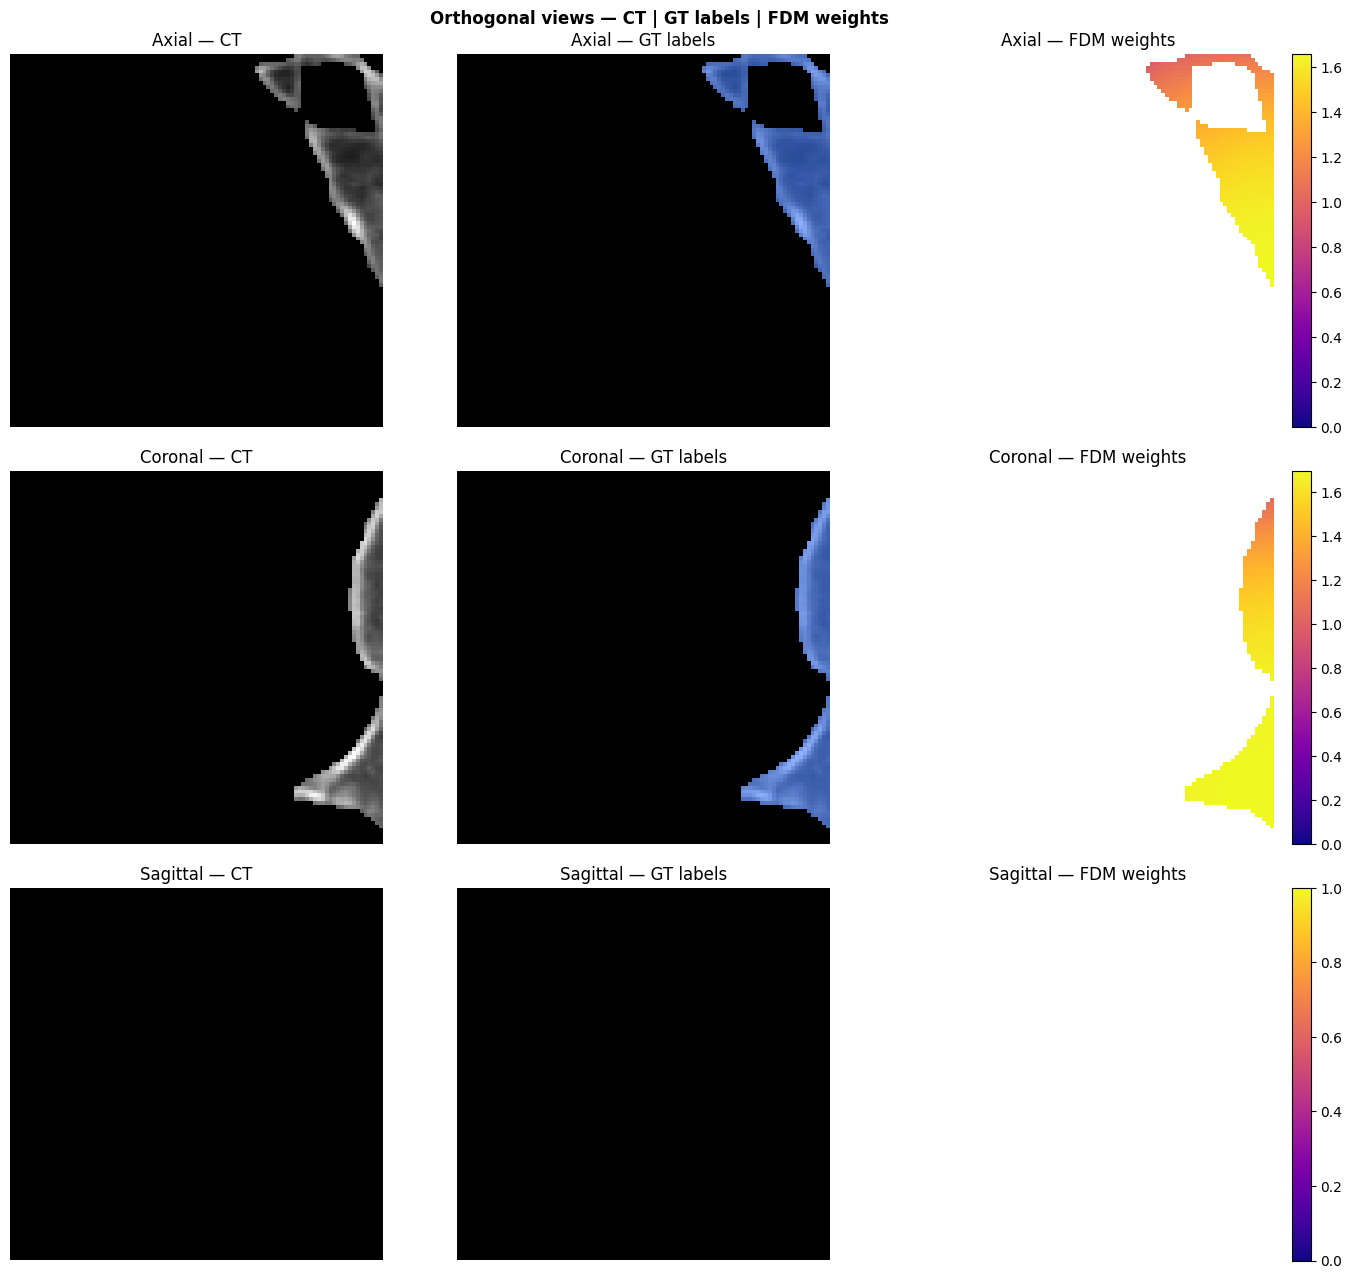

In [24]:
# Three orthogonal views for a quick 3-D sanity check
mid_d = image.shape[0] // 2
mid_h = image.shape[1] // 2
mid_w = image.shape[2] // 2

views = [
    ("Axial", image[mid_d], gt_label[mid_d], fdm_weights[mid_d]),
    ("Coronal", image[:, mid_h, :], gt_label[:, mid_h, :], fdm_weights[:, mid_h, :]),
    ("Sagittal", image[:, :, mid_w], gt_label[:, :, mid_w], fdm_weights[:, :, mid_w]),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 13))
fig.suptitle(
    "Orthogonal views — CT | GT labels | FDM weights", fontsize=12, fontweight="bold"
)

for row, (title, v_img, v_gt, v_wt) in enumerate(views):
    v_label_rgba = np.zeros((*v_gt.shape, 4))
    v_label_rgba[v_gt == 1] = [0.2, 0.45, 1.0, 0.55]
    v_label_rgba[v_gt == 2] = [1.0, 0.25, 0.25, 0.55]
    v_wt_fg = np.where(v_gt > 0, v_wt, np.nan)
    v_wt_max = np.nanmax(v_wt_fg) if not np.all(np.isnan(v_wt_fg)) else 1.0

    axes[row, 0].imshow(v_img, cmap="gray", interpolation="nearest")
    axes[row, 0].set_title(f"{title} — CT")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(v_img, cmap="gray", interpolation="nearest")
    axes[row, 1].imshow(v_label_rgba, interpolation="nearest")
    axes[row, 1].set_title(f"{title} — GT labels")
    axes[row, 1].axis("off")

    im = axes[row, 2].imshow(
        v_wt_fg, cmap="plasma", interpolation="nearest", vmin=0, vmax=v_wt_max
    )
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)
    axes[row, 2].set_title(f"{title} — FDM weights")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go


# CFS: voxels where label changes across any face-neighbour
def find_cfs_3d(lbl: np.ndarray) -> np.ndarray:
    cfs = np.zeros_like(lbl, dtype=bool)
    for axis in range(3):
        for shift in (1, -1):
            nb = np.roll(lbl, shift, axis=axis)
            edge = [slice(None)] * 3
            edge[axis] = 0 if shift == 1 else -1
            nb[tuple(edge)] = 0
            cfs |= (lbl > 0) & (nb > 0) & (nb != lbl)
    return cfs


cfs_3d = find_cfs_3d(gt_label)

maj_z, maj_y, maj_x = np.where(gt_label == 1)
min_z, min_y, min_x = np.where(gt_label == 2)
cfs_z, cfs_y, cfs_x = np.where(cfs_3d)

traces = [
    go.Scatter3d(
        x=maj_x,
        y=maj_y,
        z=maj_z,
        mode="markers",
        marker=dict(size=1.5, color="royalblue", opacity=0.15),
        name="Major fragment",
    ),
    go.Scatter3d(
        x=min_x,
        y=min_y,
        z=min_z,
        mode="markers",
        marker=dict(size=2, color="tomato", opacity=0.5),
        name="Minor fragments",
    ),
    go.Scatter3d(
        x=cfs_x,
        y=cfs_y,
        z=cfs_z,
        mode="markers",
        marker=dict(size=2.5, color="gold", opacity=1.0),
        name="CFS boundary",
    ),
]

fig = go.Figure(data=traces)
fig.update_layout(
    title=dict(text=f"3D view — {npz_path.stem}", font=dict(size=13)),
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data",
    ),
    legend=dict(itemsizing="constant"),
    margin=dict(l=0, r=0, t=40, b=0),
    height=700,
)
fig.show(renderer="browser")